# House Price Prediction with Linear Regression

## Objective

The objective of this project is to predict house prices based on their area using Simple Linear Regression.

The project includes:
- Data visualization
- Model training
- Price prediction
- Prediction for multiple house areas
- Model saving with Joblib

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

## 2. Load the Dataset

In [4]:
df = pd.read_csv('homeprices.csv')
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


## 3. Data Visualization

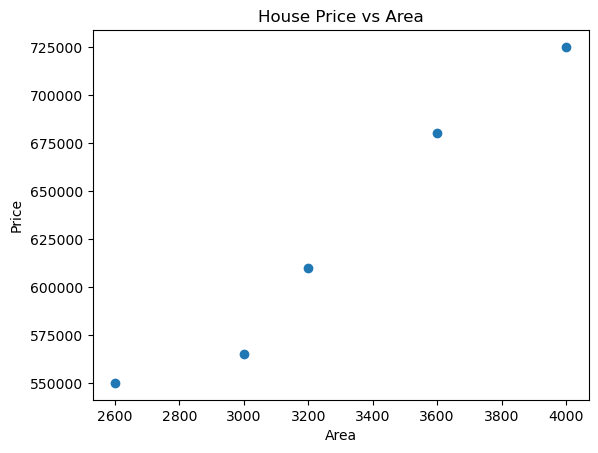

In [6]:
plt.scatter(df["area"], df["price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("House Price vs Area")
plt.show()

## 4. Train the Linear Regression Model

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
model = LinearRegression()
model.fit(df[["area"]], df["price"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
model.coef_

array([135.78767123])

In [12]:
model.intercept_

np.float64(180616.43835616432)

The regression equation is:

Price = coefficient * Area + intercept

In [15]:
print(df)

   area   price
0  2600  550000
1  3000  565000
2  3200  610000
3  3600  680000
4  4000  725000


In [16]:
new_house = pd.DataFrame({"area": [3700]})

predicted_price = model.predict(new_house)[0]

print(f"Predicted price for an area of 3700: ${predicted_price:,.2f}")

Predicted price for an area of 3700: $683,030.82


In [17]:
manual_prediction = (
    model.coef_[0] * 3700
    + model.intercept_
)

print(f"Manual prediction: ${manual_prediction:,.2f}")

Manual prediction: $683,030.82


In [19]:
model.coef_

array([135.78767123])

In [20]:
model.intercept_

np.float64(180616.43835616432)

In [21]:
model.predict([[5000]])

/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([859554.79452055])

In [22]:
area_df = pd.read_csv("areas.csv")
print(area_df)


    area
0   1000
1   1500
2   2300
3   3540
4   4120
5   4560
6   5490
7   3460
8   4750
9   2300
10  9000
11  8600
12  7100


In [23]:
area_df.head(3)


,area
0,1000
1,1500
2,2300


In [25]:
d=model.predict(area_df)
print(d)

[ 316404.10958904  384297.94520548  492928.08219178  661304.79452055
  740061.64383562  799808.21917808  926090.75342466  650441.78082192
  825607.87671233  492928.08219178 1402705.47945205 1348390.4109589
 1144708.90410959]


In [26]:
area_df['prices']=d
area_df


,area,prices
0,1000,3.164041e+05
1,1500,3.842979e+05
2,2300,4.929281e+05
3,3540,6.613048e+05
4,4120,7.400616e+05
5,4560,7.998082e+05
6,5490,9.260908e+05
7,3460,6.504418e+05
8,4750,8.256079e+05
9,2300,4.929281e+05


## 8. Visualize the Regression Line

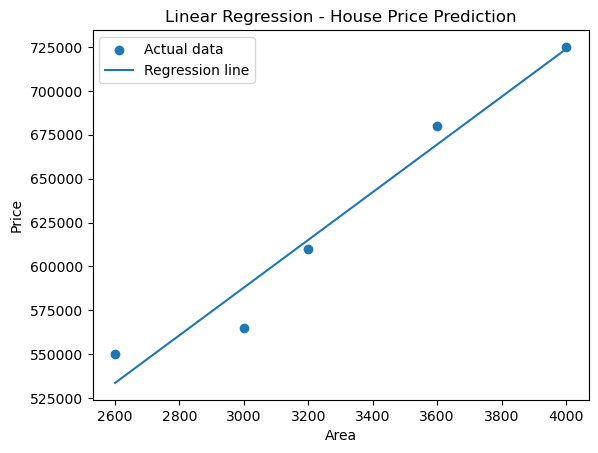

In [27]:
plt.scatter(
    df["area"],
    df["price"],
    label="Actual data"
)

plt.plot(
    df["area"],
    model.predict(df[["area"]]),
    label="Regression line"
)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Linear Regression - House Price Prediction")
plt.legend()
plt.show()

Save Trained Model Using joblib

## 9. Save the Trained Model

In [28]:
 import joblib

In [29]:
joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [30]:
loaded_model = joblib.load("house_price_model.pkl")

In [32]:
loaded_model.coef_

array([135.78767123])

In [33]:
loaded_model.intercept_

np.float64(180616.43835616432)

In [34]:
test_house = pd.DataFrame({"area": [3700]})

loaded_model.predict(test_house)

array([683030.82191781])

## Conclusion

This project demonstrated how Simple Linear Regression can be used to predict house prices based on house area.

The trained model was used to:
- Estimate prices for new house areas
- Generate predictions for multiple observations
- Visualize the regression line
- Save and reload the trained model using Joblib